In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
raw_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\edgar_f\RawData_1E68_SEP_01_15.xlsx')
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 53115 entries, 0 to 53114
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  53115 non-null  str  
 1   Message  53115 non-null  str  
 2   Status   53115 non-null  str  
dtypes: str(3)
memory usage: 1.2 MB


In [3]:
aux=pd.DataFrame()
aux=raw_data
aux['Headers']='NaN'

for i in range(0,aux.shape[0]):
    aux.iloc[i,3]=aux.iloc[i,2][0:8]

aux['Headers'].value_counts()

Headers
0x252514    49607
0x252513     2971
0x252501      287
0x252511      250
Name: count, dtype: int64

In [4]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 53115 entries, 0 to 53114
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  53115 non-null  str  
 1   Message  53115 non-null  str  
 2   Status   53115 non-null  str  
 3   Headers  53115 non-null  str  
dtypes: str(4)
memory usage: 1.6 MB


Odometer

In [5]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux['Odometer in meters']=0.0
odometer=[]
date=[]
raw=[]
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    odometer.append(int(unit_aux.iloc[i,2][96:104],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Odometer in meters']=odometer
unit_aux['Date']=date
unit_aux['Raw data']=raw

#print(unit_aux['Odometer in meters'])

unit=unit_aux.sort_values('Date',ascending=True)

print(unit.info())

<class 'pandas.DataFrame'>
Index: 52578 entries, 38070 to 53114
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Created             52578 non-null  str  
 1   Message             52578 non-null  str  
 2   Status              52578 non-null  str  
 3   Headers             52578 non-null  str  
 4   Odometer in meters  52578 non-null  int64
 5   Date                52578 non-null  str  
 6   Raw data            52578 non-null  str  
dtypes: int64(1), str(6)
memory usage: 3.2 MB
None


000101000005 -> 0 -> 608562.0 -> 0x252514005904C30869487064444259003C38402D00000000EF00000000000041000000FFFFFFFFFFFFFFFFFFFF428000094932840001010000053333F2423D3A99C2AB1FA8400000004403852829FFFFFF00002EFFFFFFFFFF
000101000005 -> 1 -> 604164.0 -> 0x25251400597DB90869487064444259003C38402D00000000EA00000000000061000000FFFFFFFFFFFFFFFFFFFF438000093804820001010000059A99D742843999C2BC1EA8400000000003852816FFFFFF00002FFFFFFFFFFF
000101000005 -> 2 -> 604164.0 -> 0x25251400597D9B0869487064444259003C38402D00000000E900000000000061000000FFFFFFFFFFFFFFFFFFFF438000093804820001010000059A99D742843999C2BC1EA8400000000003852819FFFFFF00002FFFFFFFFFFF
000101000005 -> 3 -> 608562.0 -> 0x252514005904B00869487064444259003C38402D00000000EF00000000000061000000FFFFFFFFFFFFFFFFFFFF438000094932840001010000053333F2423D3A99C2AB1FA8400000004403852829FFFFFF00002EFFFFFFFFFF
000101000006 -> 4 -> 604164.0 -> 0x25251400597B950869487064444259003C38402D00000000EF00000000000061000000FFFFFFFFFFFFFFFFFFFF4380000938048200010

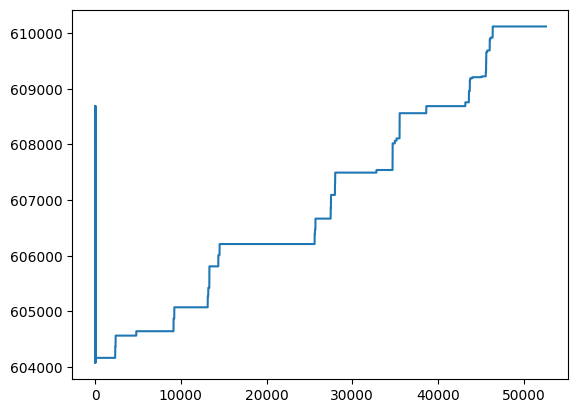

In [6]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,4]))
    x_axis.append(i)
    date.append(unit.iloc[i,5])
    raw_data_.append(unit.iloc[i,6])

#print("Delta odometer: ",y_axis[170]-y_axis[133],'meters')

for i in range(0,len(odometer)):
    print(date[i],'->',x_axis[i],'->',y_axis[i],'->',raw_data_[i])

#print(odometer[len(odometer)-1]-odometer[0])
plt.plot(x_axis,y_axis)

Speed

In [7]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
#unit_aux['Odometer in meters']=0.0
speed=[]
date=[]
raw=[]
unit_speed=pd.DataFrame()
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    try:
        lbs_ind=(bin(int(unit_aux.iloc[i,2][50:52],16) & 64))
        if lbs_ind=='0b1000000':
            speed.append(int(unit_aux.iloc[i,2][142:145]))  
            date.append(unit_aux.iloc[i,2][106:118])
            raw.append(unit_aux.iloc[i,2])
            #print(lbs_ind)

    except:
        pass    

unit_speed['Speed']=speed
unit_speed['Date']=date
unit_speed['Raw data']=raw

unit=unit_speed.sort_values('Date',ascending=True)

print(unit.info())

<class 'pandas.DataFrame'>
Index: 52566 entries, 38665 to 52565
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Speed     52566 non-null  int64
 1   Date      52566 non-null  str  
 2   Raw data  52566 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.6 MB
None


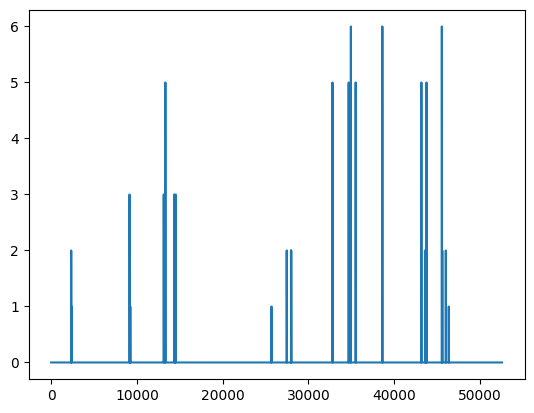

In [8]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,0]))
    x_axis.append(i)
    date.append(unit.iloc[i,1])
    raw_data_.append(unit.iloc[i,2])
    #print(raw_data_[i])

for i in range(0,len(speed)):
    if (y_axis[i]>55):
        print(date[i],'->',x_axis[i],'->',y_axis[i],'->',raw_data_[i])

plt.plot(x_axis,y_axis)

Satellites

In [9]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
satellite_number=[]
satellite_connection_indicator=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    satellite_number.append(int(unit_aux.iloc[i,2][50:52],16) & 31)
    satellite_connection_indicator.append(int(unit_aux.iloc[i,2][50:52],16) & 128)
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Satellites']=satellite_number
unit_aux['Satellite_connection_indicator']=satellite_connection_indicator
unit_aux['Raw data']=raw
unit_aux['date']=date

unit=unit_aux.sort_values('date',ascending=True)
unit.info()

for i in range(0,unit.shape[0]):
    if unit.iloc[i,4]<1:
        num_events=num_events+1
        print(unit.iloc[i,0], '->',unit.iloc[i,4],'->',unit.iloc[i,5],'->',unit.iloc[i,6])

print("Eventos históricos: ",num_events)

<class 'pandas.DataFrame'>
Index: 52578 entries, 38070 to 53114
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Created                         52578 non-null  str  
 1   Message                         52578 non-null  str  
 2   Status                          52578 non-null  str  
 3   Headers                         52578 non-null  str  
 4   Satellites                      52578 non-null  int64
 5   Satellite_connection_indicator  52578 non-null  int64
 6   Raw data                        52578 non-null  str  
 7   date                            52578 non-null  str  
dtypes: int64(2), str(6)
memory usage: 3.6 MB
2026-09-01 20:55:08.909 -> 0 -> 128 -> 0x2525140059814B0869487064444259003C38402D0000001B8000000000000061000000FFFFFFFFFFFFFFFFFFFF43D0000938048100010100001282DC006500189101715100150000000003842817FFFFFF000035FFFFFFFFFF
2026-09-10 20:44:36.030 -> 0 -> 128 -> 0x2525140

In/Outs

15      14                 13      12      11      10      09      08       07 06 05 04 03 02 01 00
Power   Ignition/Input0    Input1  Input2  Input3  Input4  Input5  Input0

15=0, Connected
15=1. Disconnected

In [10]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux.info()
aux_cad=[]
aux_date=[]
aux_raw_data=[]
aux_input_number=[]
in_outs=[]

#unit_aux.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\concatenated.csv')

for i in range(0,unit_aux.shape[0]):
    long_cad=len(unit_aux.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(unit_aux.iloc[i,2])   

for i in range(0,len(aux_cad)):
    aux_value=aux_cad[i][64:68]
    aux_date.append(aux_cad[i][106:118])
    aux_raw_data.append(aux_cad[i])
    in_outs.append(bin (int (aux_cad[i][64:68],16)))      

unit_=pd.DataFrame()
unit_['in and outs']=in_outs
unit_['date']=aux_date
unit_['raw data']=aux_raw_data

in_outs_df=unit_.sort_values('date',ascending=True)

in_outs_df.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\edgar_f\in_outs_1E68_1.csv')

<class 'pandas.DataFrame'>
Index: 52578 entries, 50 to 53114
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  52578 non-null  str  
 1   Message  52578 non-null  str  
 2   Status   52578 non-null  str  
 3   Headers  52578 non-null  str  
dtypes: str(4)
memory usage: 2.0 MB


Ignition

In [11]:
in_outs_df.info()

for i in range(0,in_outs_df.shape[0]):
    length=len(in_outs_df.iloc[i,0])
    if length>16:
        aux_ign=in_outs_df.iloc[i,0][2:3]
        if aux_ign=='1':
            print("Ignition On",in_outs_df.iloc[i,0])
        if aux_ign=='0':
            print("Ignition Off",in_outs_df.iloc[i,0])
    else:
        aux_ign=in_outs_df.iloc[i,0][2:3]
        if aux_ign=='1':
            print("Ignition On",in_outs_df.iloc[i,0])
        if aux_ign=='0':
            print("Ignition Off",in_outs_df.iloc[i,0])

<class 'pandas.DataFrame'>
Index: 52578 entries, 38669 to 52577
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   in and outs  52578 non-null  str  
 1   date         52578 non-null  str  
 2   raw data     52578 non-null  str  
dtypes: str(3)
memory usage: 1.6 MB
Ignition On 0b100000100000000
Ignition On 0b110000100000000
Ignition On 0b110000100000000
Ignition On 0b110000100000000
Ignition On 0b110000100000000
Ignition On 0b110000100000000
Ignition On 0b110000100000000
Ignition On 0b100000100000000
Ignition On 0b110000100000000
Ignition On 0b110000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b110000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b110000100000000
Ignition On 0b100000100000000
Ignition On 0b110000100000000
Ignition

Power

In [12]:
ext_bat_13=raw_data[raw_data['Status'].str.contains('0x252513')]
ext_bat_14=raw_data[raw_data['Status'].str.contains('0x252514')]
ext_bat_vol=pd.concat([ext_bat_13,ext_bat_14])
ext_bat=[]
date_bat=[]
bat_df=pd.DataFrame()

ext_bat_vol.info()

for i in range(0,ext_bat_vol.shape[0]):
    val=(float(ext_bat_vol.iloc[i,2][154:158]))/100
    date_bat.append(ext_bat_vol.iloc[i,2][106:119])
    ext_bat.append(val)
#print(ext_bat)

for i in range(0,ext_bat_vol.shape[0]):
    if ext_bat[i]<3:
        bat_df['Date']=date_bat
        bat_df['int_bat']=ext_bat

print(bat_df)

<class 'pandas.DataFrame'>
Index: 52578 entries, 50 to 53114
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  52578 non-null  str  
 1   Message  52578 non-null  str  
 2   Status   52578 non-null  str  
 3   Headers  52578 non-null  str  
dtypes: str(4)
memory usage: 2.0 MB
Empty DataFrame
Columns: []
Index: []


Pánico

In [13]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux.info()
aux_cad=[]
aux_date=[]
aux_raw_data=[]
aux_input_number=[]

#unit_aux.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\concatenated.csv')

for i in range(0,unit_aux.shape[0]):
    long_cad=len(unit_aux.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(unit_aux.iloc[i,2])   

for i in range(0,len(aux_cad)):
    aux_value=aux_cad[i][92:94]
    aux_date.append(aux_cad[i][106:118])
    #aux_raw_data.append(aux_cad[i])
    if aux_value=='03':
        print(aux_value, ' -> ',aux_date[i])    

print("len aux_cad: ",len(aux_cad))

<class 'pandas.DataFrame'>
Index: 52578 entries, 50 to 53114
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  52578 non-null  str  
 1   Message  52578 non-null  str  
 2   Status   52578 non-null  str  
 3   Headers  52578 non-null  str  
dtypes: str(4)
memory usage: 2.0 MB
len aux_cad:  52578
